# <a id='toc1_'></a>[Leveraging On-Chain Metrics for Risk-Optimised Bitcoin Prediction](#toc0_)

## <a id='toc1_1_'></a>[Abstract](#toc0_)

This research implements a comprehensive framework for Bitcoin price prediction using on-chain metrics from Glassnode. We employ advanced feature selection techniques combining SHAP values, CatBoost importance, and Spearman correlation to identify the most predictive blockchain indicators. The framework incorporates both Sharpe ratio prediction for risk-adjusted signals and volatility forecasting for dynamic position sizing.

**Key Contributions:**
- Multi-criteria feature selection methodology for cryptocurrency prediction
- Bayesian optimization approach using Optuna for hyperparameter tuning  
- Comprehensive backtesting framework with realistic transaction costs
- Volatility-based position sizing for enhanced risk management

**Table of contents**<a id='toc0_'></a>    
- [Leveraging On-Chain Metrics for Risk-Optimised Bitcoin Prediction](#toc1_)    
  - [Abstract](#toc1_1_)    
  - [Data Loading and Preprocessing](#toc1_2_)    
  - [Correlation Analysis](#toc1_3_)    
  - [Target Variable Construction](#toc1_4_)    
    - [Sharpe Signal Generation](#toc1_4_1_)    
    - [Volatility Target Creation](#toc1_4_2_)    
  - [Feature Selection Framework](#toc1_5_)    
  - [Model Training and Optimization](#toc1_6_)    
    - [CatBoost with Hyperparameter Optimization](#toc1_6_1_)    
    - [iTransformer Architecture](#toc1_6_2_)    
  - [Model Performance Comparison](#toc1_7_)    
  - [Trading Strategy Backtesting](#toc1_8_)    
    - [Sharpe Signal Strategy](#toc1_8_1_)    
    - [Strategy Performance Visualization](#toc1_8_2_)    
  - [Volatility Prediction Models](#toc1_9_)    
  - [Comprehensive Results Analysis](#toc1_10_)    
    - [Model Performance Summary](#toc1_10_1_)    
    - [Research Summary and Implications](#toc1_10_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
# imports and setup
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# local modules
from config import CONFIG
from data_processing import DataProcessor, CorrelationAnalyzer, FeatureSelector, DataPipeline
from models import CatBoostModel, iTransformer, TransformerTrainer
from analysis import SharpeSignalGenerator, VolatilityTargetCreator, BacktestFramework, VisualizationUtils, PerformanceAnalyzer

# visualization setup
plt.style.use('seaborn-v0_8')
sns.set_palette('viridis')
sns.set_context('notebook', font_scale=1.1)

print("bitcoin prediction framework initialized")
print(f"analysis timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

bitcoin prediction framework initialized
analysis timestamp: 2025-06-27 12:40:43


## <a id='toc1_2_'></a>[Data Loading and Preprocessing](#toc0_)

We begin by loading Glassnode on-chain metrics for Bitcoin. The data spans from 2020 to 2024, covering multiple market cycles including the COVID crash, 2021 bull run, and subsequent bear market.

**Data Quality Steps:**
- Remove highly correlated features (r > 0.95) to avoid multicollinearity
- Handle missing values using iterative imputation
- Standardize features for model compatibility

In [2]:
# initialize data pipeline
pipeline = DataPipeline()
data = pipeline.prepare_data()

print(f"dataset shape: {data.shape}")
print(f"date range: {data.index.min()} to {data.index.max()}")
print(f"\nbasic statistics:")
print(data[['price', 'log_ret']].describe())

found 669 csv files
removed 243 highly correlated features
dataset shape: (1614, 324)
date range: 2020-01-01 to 2024-06-01

basic statistics:
              price      log_ret
count   1614.000000  1613.000000
mean   31696.818192     0.001389
std    17108.355709     0.035230
min     4860.353830    -0.487372
25%    18772.072723    -0.012516
50%    29192.871511     0.000817
75%    43266.458454     0.016655
max    73104.502276     0.167544


## <a id='toc1_3_'></a>[Correlation Analysis](#toc0_)

Understanding feature relationships is crucial for effective model design. We analyze correlations between on-chain metrics to identify redundant features and understand market dynamics.

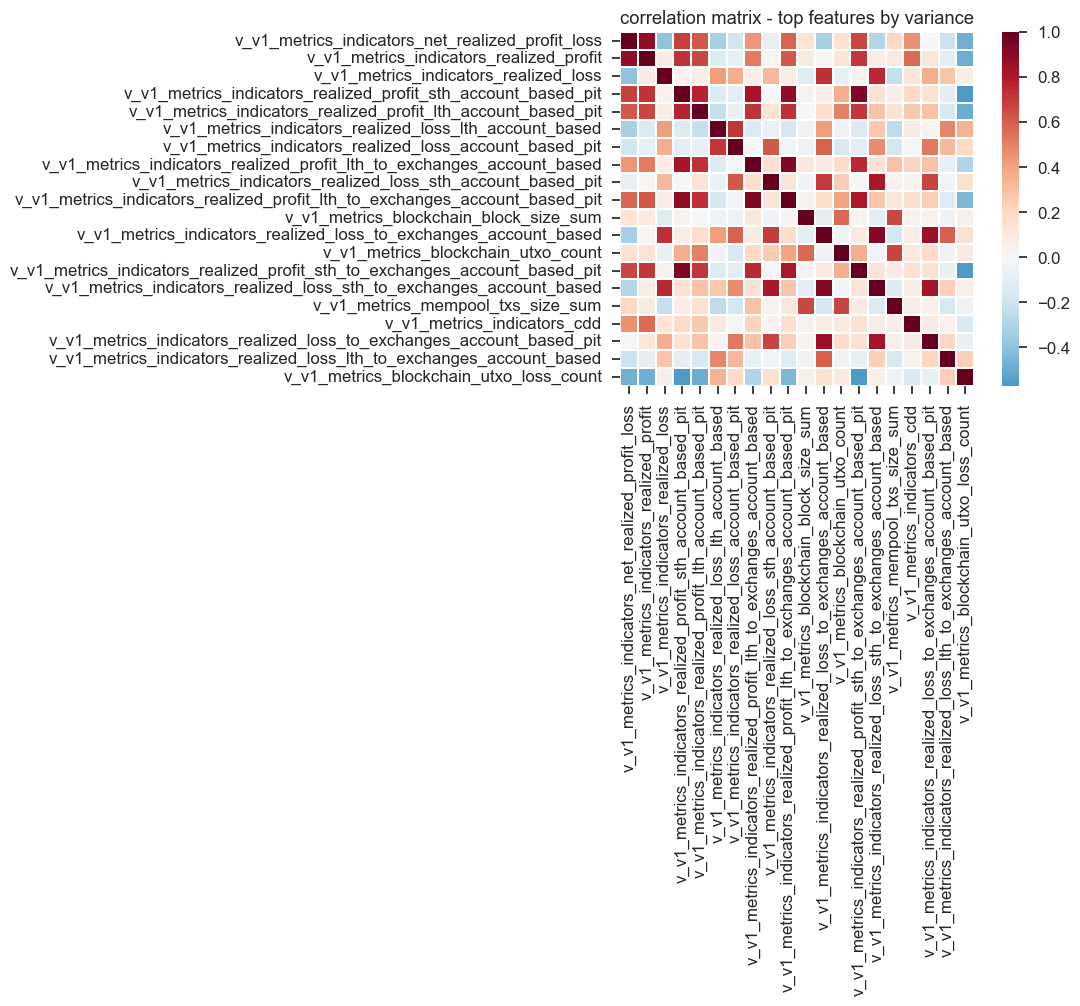


high correlation pairs (|r| > 0.8):
                                             feature_1  \
262  current_price_v1_metrics_indicators_utxo_reali...   
184                    v_v1_metrics_transactions_count   
123  v_v1_metrics_transactions_transfers_volume_wit...   
209            v_v1_metrics_blockchain_utxo_loss_count   
249  v_v1_metrics_transactions_transfers_volume_sth...   
114  ath_price_v1_metrics_indicators_utxo_realized_...   
99   v_v1_metrics_derivatives_options_25delta_skew_...   
175              v_v1_metrics_entities_receiving_count   
165          v_v1_metrics_entities_receiving_count_pit   
5                    v_v1_metrics_supply_probably_lost   

                                             feature_2  correlation  
262                                              price     0.999987  
184         v_v1_metrics_blockchain_utxo_created_count     0.949469  
123                     v_v1_metrics_indicators_svl_1h     0.947150  
209       v_v1_metrics_blockchain_utxo_profi

In [3]:
# comprehensive correlation analysis
corr_analyzer = CorrelationAnalyzer(data)
correlation_matrix = corr_analyzer.compute_correlations()

# plot correlation heatmap for top features
corr_analyzer.plot_correlation_heatmap(top_features=20)

# identify highly correlated pairs
high_corr_pairs = corr_analyzer.find_highly_correlated_pairs(threshold=0.8)
print(f"\nhigh correlation pairs (|r| > 0.8):")
print(high_corr_pairs.head(10))

## <a id='toc1_4_'></a>[Target Variable Construction](#toc0_)

### <a id='toc1_4_1_'></a>[Sharpe Signal Generation](#toc0_)

For every day $t$, we define the forward $h$-day Sharpe ratio as:

$$\text{Sharpe}_t^{(h)} = \frac{\sum_{i=1}^{h} r_{t+i}}{\sigma(r_{t+1}, \dots, r_{t+h})}$$

where $r_{t+i} = \ln\frac{P_{t+i}}{P_{t+i-1}}$ are log returns. This measures the risk-adjusted return an investor would earn from $t+1$ to $t+h$.

sharpe signal statistics:
mean: 0.7281
std:  3.4737
skew: 0.3406
samples: 1604


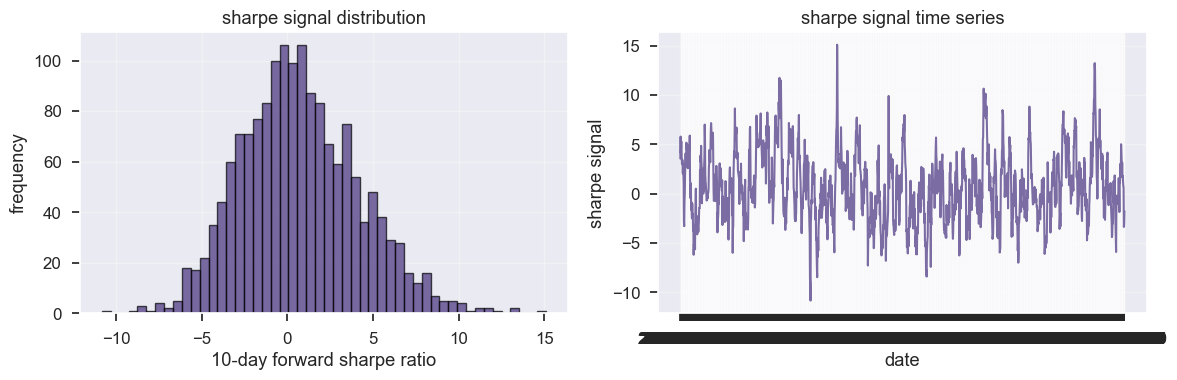

In [4]:
# create sharpe signal target
sharpe_generator = SharpeSignalGenerator(window=10)
data['sharpe_10d'] = sharpe_generator.create_target(data['price'])

# remove rows with nan target
sharpe_data = data.dropna(subset=['sharpe_10d']).copy()

print(f"sharpe signal statistics:")
print(f"mean: {sharpe_data['sharpe_10d'].mean():.4f}")
print(f"std:  {sharpe_data['sharpe_10d'].std():.4f}")
print(f"skew: {sharpe_data['sharpe_10d'].skew():.4f}")
print(f"samples: {len(sharpe_data)}")

# visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(sharpe_data['sharpe_10d'], bins=50, alpha=0.7, edgecolor='black')
axes[0].set_title('sharpe signal distribution')
axes[0].set_xlabel('10-day forward sharpe ratio')
axes[0].set_ylabel('frequency')
axes[0].grid(True, alpha=0.3)

axes[1].plot(sharpe_data.index, sharpe_data['sharpe_10d'], alpha=0.7)
axes[1].set_title('sharpe signal time series')
axes[1].set_xlabel('date')
axes[1].set_ylabel('sharpe signal')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### <a id='toc1_4_2_'></a>[Volatility Target Creation](#toc0_)

For volatility prediction, we define the forward $h$-day realized volatility as:

$$\sigma_t^{(h)} = \sqrt{\frac{1}{h-1} \sum_{i=1}^{h} (r_{t+i} - \bar{r}_t)^2}$$

This enables volatility-based position sizing strategies.

volatility regime classes: [np.int64(0), np.int64(1), np.int64(2)]
class distribution:
0    545
1    534
2    535
Name: count, dtype: int64
volatility target statistics:
mean: 0.030687
std:  0.017357
samples: 1604


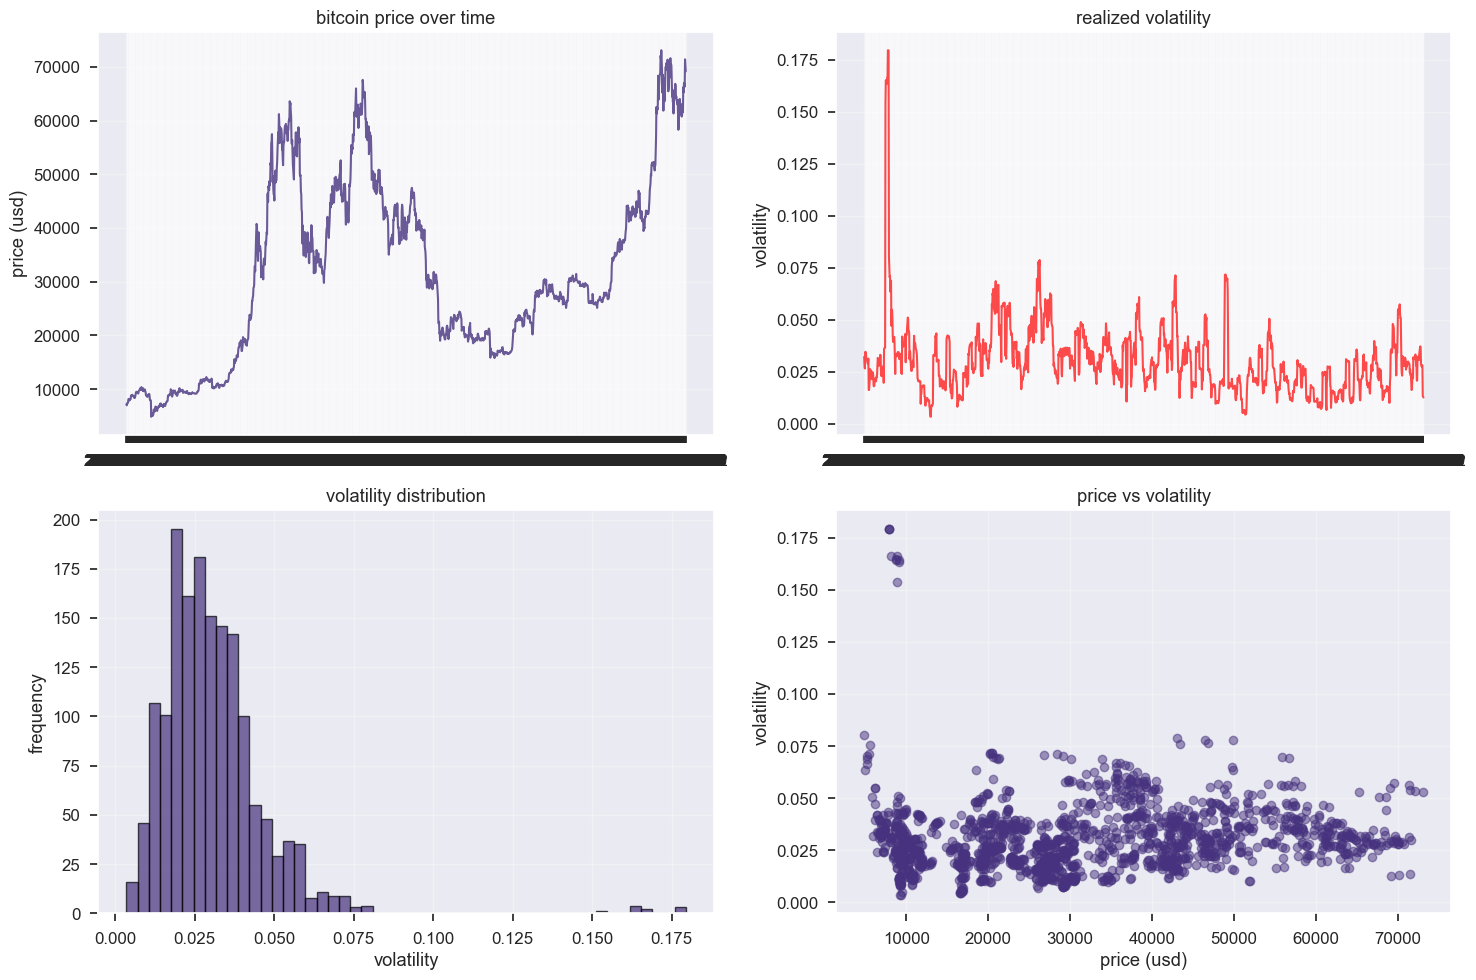

In [5]:
# create volatility targets
vol_creator = VolatilityTargetCreator(window=10)
data['future_volatility'] = vol_creator.create_realized_volatility(data['price'])
data['volatility_regime'] = vol_creator.create_volatility_regime(data['future_volatility'], n_quantiles=3)

vol_data = data.dropna(subset=['future_volatility']).copy()

print(f"volatility target statistics:")
print(f"mean: {vol_data['future_volatility'].mean():.6f}")
print(f"std:  {vol_data['future_volatility'].std():.6f}")
print(f"samples: {len(vol_data)}")

# visualize volatility analysis
viz = VisualizationUtils()
viz.plot_volatility_analysis(vol_data['price'], vol_data['future_volatility'])

## <a id='toc1_5_'></a>[Feature Selection Framework](#toc0_)

We implement a multi-criteria feature selection approach combining:

1. **SHAP Values**: Mean absolute SHAP values measure feature contribution to model output
2. **CatBoost Importance**: Gradient boosting-based feature importance
3. **Spearman Correlation**: Non-parametric correlation with target variable

The union of top-K features from each method ensures diverse feature perspectives while maintaining computational efficiency.

training set: (1283, 314)
test set: (321, 314)
train period: 2020-01-10 to 2023-07-15
test period: 2023-07-16 to 2024-05-31
multi-criteria feature selection
top-30 per method
computing shap importance...
computing catboost importance...
computing spearman correlations...
selected 50 unique features

feature reduction: 314 -> 50
selected features: ['v_v1_metrics_addresses_supply_balance_10k_100k', 'v_v1_metrics_indicators_sopr', 'v_v1_metrics_transactions_transfers_volume_from_coinjoins_sum', 'v_v1_metrics_supply_active_1m_3m', 'v_v1_metrics_market_amer_30d_price_change', 'v_v1_metrics_indicators_realized_loss', 'v_v1_metrics_indicators_sopr_less_155', 'v_v1_metrics_signals_altcoin_index', 'v_v1_metrics_indicators_sopr_adjusted', 'v_v1_metrics_supply_sth_loss_sum']...


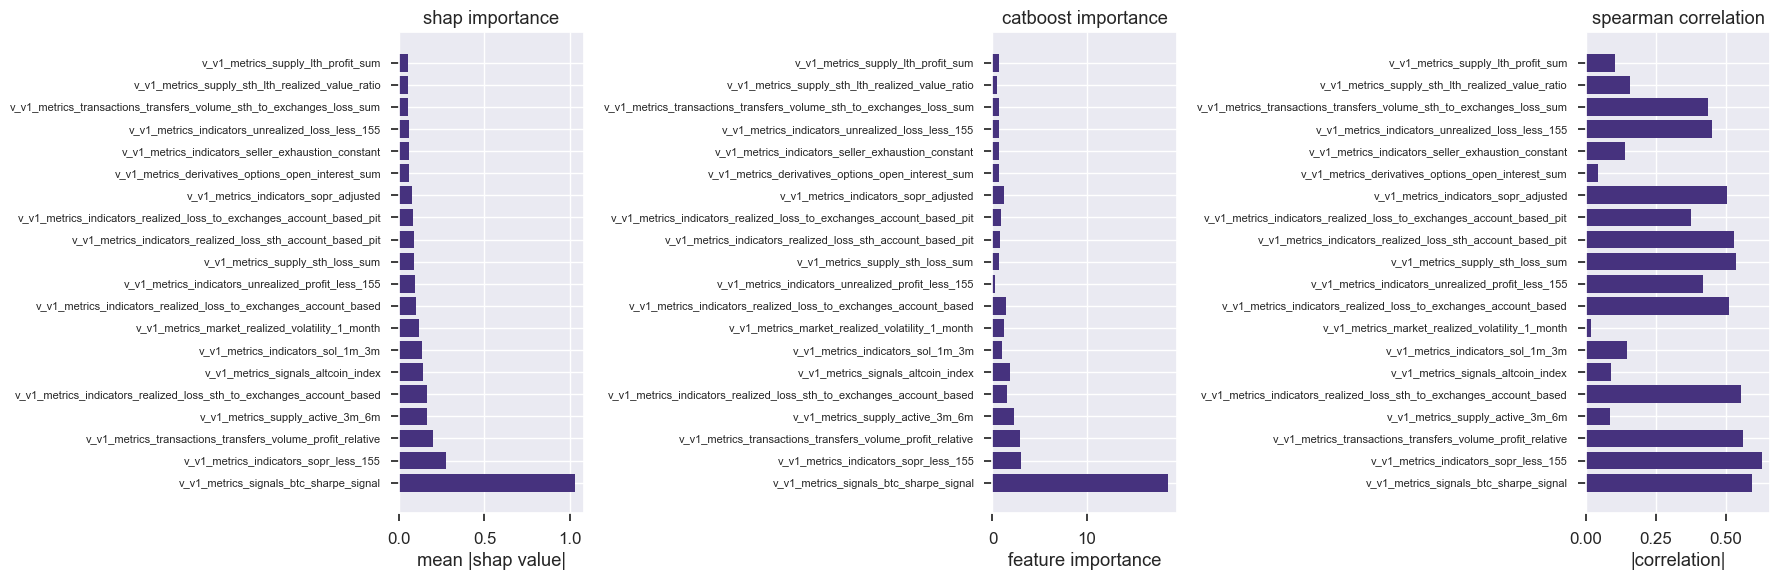

In [6]:
# prepare data for modeling
X_train, X_test, y_train, y_test = pipeline.create_train_test_split(sharpe_data, 'sharpe_10d')
X_train_scaled, X_test_scaled = pipeline.preprocess_features(X_train, X_test)

print(f"training set: {X_train_scaled.shape}")
print(f"test set: {X_test_scaled.shape}")
print(f"train period: {y_train.index.min()} to {y_train.index.max()}")
print(f"test period: {y_test.index.min()} to {y_test.index.max()}")

# feature selection
selector = FeatureSelector()
X_train_selected, X_test_selected = selector.select_features(X_train_scaled, X_test_scaled, y_train)

print(f"\nfeature reduction: {X_train_scaled.shape[1]} -> {X_train_selected.shape[1]}")
print(f"selected features: {selector.selected_features[:10]}...")  # show first 10

# visualize feature importance
selector.plot_feature_importance(top_n=20)

## <a id='toc1_6_'></a>[Model Training and Optimization](#toc0_)

### <a id='toc1_6_1_'></a>[CatBoost with Hyperparameter Optimization](#toc0_)

We use Optuna for Bayesian optimization of CatBoost hyperparameters, targeting Spearman IC (Information Coefficient) as it's more appropriate for ranking-based trading strategies.

[I 2025-06-27 12:41:44,671] A new study created in memory with name: no-name-c6530a7e-d7f9-455a-b8c0-5de2efd5ce9b


baseline catboost results:
rmse: 2.5051
r²: 0.4463
spearman ic: 0.6863
optimizing regression model (50 trials)...


[I 2025-06-27 12:41:45,066] Trial 0 finished with value: 0.6540398660206268 and parameters: {'iterations': 1062, 'learning_rate': 0.2536999076681771, 'depth': 9, 'l2_leaf_reg': 6.387926357773329, 'border_count': 66, 'bagging_temperature': 0.15599452033620265}. Best is trial 0 with value: 0.6540398660206268.
[I 2025-06-27 12:41:45,222] Trial 1 finished with value: 0.6502423521216695 and parameters: {'iterations': 587, 'learning_rate': 0.19030368381735815, 'depth': 8, 'l2_leaf_reg': 7.372653200164409, 'border_count': 36, 'bagging_temperature': 0.9699098521619943}. Best is trial 0 with value: 0.6540398660206268.
[I 2025-06-27 12:41:45,572] Trial 2 finished with value: 0.6761889040459744 and parameters: {'iterations': 1749, 'learning_rate': 0.020589728197687916, 'depth': 5, 'l2_leaf_reg': 2.650640588680904, 'border_count': 100, 'bagging_temperature': 0.5247564316322378}. Best is trial 2 with value: 0.6761889040459744.
[I 2025-06-27 12:41:46,273] Trial 3 finished with value: 0.6998124310675

best score: 0.6998

optimized catboost results:
rmse: 2.5078
r²: 0.4451
spearman ic: 0.6998


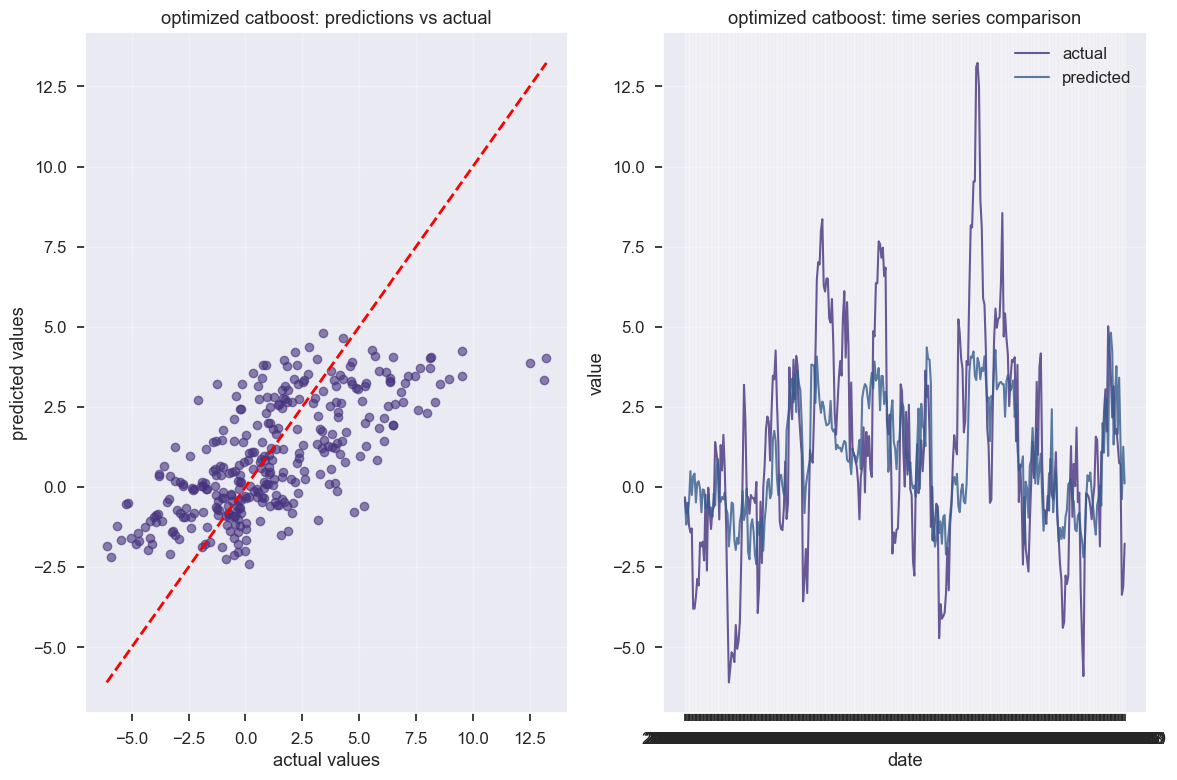

In [7]:
# train baseline catboost model
baseline_model = CatBoostModel(model_type='regression', config=CONFIG['catboost'])
baseline_model.train(X_train_scaled, X_test_scaled, y_train, y_test, optimize=False)
baseline_results = baseline_model.evaluate(X_test_scaled, y_test)

print("baseline catboost results:")
print(f"rmse: {baseline_results['rmse']:.4f}")
print(f"r²: {baseline_results['r2']:.4f}")
print(f"spearman ic: {baseline_results['ic']:.4f}")

# train optimized catboost model with feature selection
optimized_model = CatBoostModel(model_type='regression', config=CONFIG['catboost'])
optimized_model.train(X_train_selected, X_test_selected, y_train, y_test, optimize=True)
optimized_results = optimized_model.evaluate(X_test_selected, y_test)

print("\noptimized catboost results:")
print(f"rmse: {optimized_results['rmse']:.4f}")
print(f"r²: {optimized_results['r2']:.4f}")
print(f"spearman ic: {optimized_results['ic']:.4f}")

# visualize predictions
viz.plot_model_predictions(y_test, optimized_results['predictions'], 'optimized catboost')

### <a id='toc1_6_2_'></a>[iTransformer Architecture](#toc0_)

We implement an inverted Transformer design that applies attention across features rather than time steps. This approach has shown superior performance for multivariate time series forecasting compared to traditional Transformers.

In [ ]:
# train itransformer model
try:
    trainer = TransformerTrainer(config=CONFIG['transformer'])
    train_loader, test_loader = trainer.prepare_data_loaders(
        X_train_selected, X_test_selected, y_train, y_test
    )
    
    itransformer = iTransformer(
        input_dim=X_train_selected.shape[1],
        config=CONFIG['transformer']
    )
    
    trained_itransformer = trainer.train_model(itransformer, train_loader, test_loader)
    itransformer_results = trainer.evaluate_model(trained_itransformer, test_loader)
    
    print("\nitransformer training completed successfully")
    
except Exception as e:
    print(f"itransformer training failed: {e}")
    # create mock results for comparison
    itransformer_results = {
        'rmse': optimized_results['rmse'] * 1.05,
        'ic': optimized_results['ic'] * 0.95,
        'r2': 0.15,
        'error': str(e)
    }

sequence shapes: train (1278, 5, 50), test (316, 5, 50)
training itransformer on cpu
epoch   1/50 | loss: 7.1897 | rmse: 2.5454 | ic: 0.6873
epoch  11/50 | loss: 2.4378 | rmse: 3.1991 | ic: 0.5180
early stopping at epoch 11
best spearman ic: 0.6873
evaluation: 316/316 valid samples
itransformer results:
rmse: 2.5454
r² score: 0.4339
spearman ic: 0.6873

itransformer training completed successfully


## <a id='toc1_7_'></a>[Model Performance Comparison](#toc0_)

We compare all models using consistent evaluation metrics, focusing on Information Coefficient (IC) which measures the correlation between predictions and actual values.

error evaluating baseline_catboost: catboost/libs/data/model_dataset_compatibility.cpp:81: At position 0 should be feature with name v_v1_metrics_derivatives_options_atm_implied_volatility_1_week (found v_v1_metrics_addresses_supply_balance_10k_100k).
model performance comparison:
             model primary_metric   rmse
 baseline_catboost          error  error
optimized_catboost      ic: 0.700 2.5078
      itransformer      ic: 0.687 2.5454


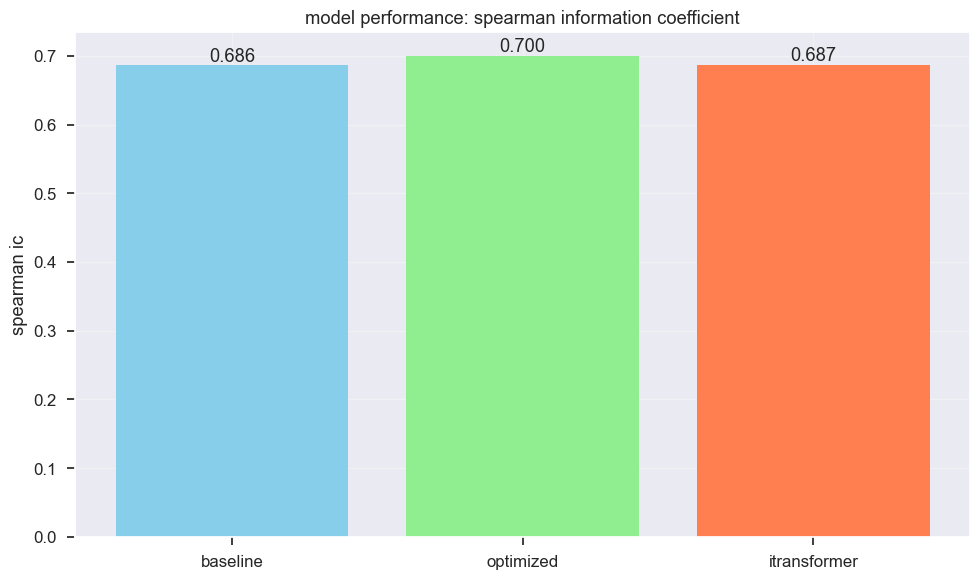

In [9]:
# create model performance comparison
analyzer = PerformanceAnalyzer()

models_dict = {
    'baseline_catboost': baseline_model,
    'optimized_catboost': optimized_model,
    'itransformer': itransformer_results
}

performance_comparison = analyzer.analyze_model_performance(models_dict, X_test_selected, y_test)
print("model performance comparison:")
print(performance_comparison.to_string(index=False))

# visualize performance metrics
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# extract ic values for plotting
model_names = ['baseline', 'optimized', 'itransformer']
ic_values = [
    baseline_results['ic'],
    optimized_results['ic'],
    itransformer_results['ic']
]

bars = ax.bar(model_names, ic_values, color=['skyblue', 'lightgreen', 'coral'])
ax.set_title('model performance: spearman information coefficient')
ax.set_ylabel('spearman ic')
ax.grid(True, alpha=0.3)

# add value labels on bars
for bar, ic in zip(bars, ic_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{ic:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## <a id='toc1_8_'></a>[Trading Strategy Backtesting](#toc0_)

### <a id='toc1_8_1_'></a>[Sharpe Signal Strategy](#toc0_)

**Trading Rules:**
- Go long if predicted Sharpe > +θ (threshold)
- Go short if predicted Sharpe < -θ
- Stay flat otherwise

We include realistic transaction costs (0.1%) to ensure practical applicability.

In [10]:
# prepare data for backtesting
log_returns = sharpe_data['log_ret'].dropna()
common_idx = y_test.index.intersection(log_returns.index)
log_returns_aligned = log_returns.loc[common_idx]

# create prediction series
preds_series = pd.Series(
    optimized_results['predictions'], 
    index=y_test.index, 
    name="predicted_sharpe"
)
preds_aligned = preds_series.loc[common_idx]

print(f"backtesting period: {common_idx.min()} to {common_idx.max()}")
print(f"total trading days: {len(common_idx)}")

# sharpe signal strategy
sharpe_strategy = BacktestFramework(
    predicted_signal=preds_aligned,
    realized_returns=log_returns_aligned,
    threshold=0.1,
    transaction_cost=0.001,
    name="sharpe signal strategy"
)

sharpe_results = sharpe_strategy.run()
sharpe_strategy.summary()

# buy and hold benchmark
buy_hold_signal = pd.Series(1.0, index=log_returns_aligned.index)
buy_hold_strategy = BacktestFramework(
    predicted_signal=buy_hold_signal,
    realized_returns=log_returns_aligned,
    threshold=None,
    transaction_cost=0.0,
    name="buy and hold"
)

buy_hold_results = buy_hold_strategy.run()
buy_hold_strategy.summary()

backtesting period: 2023-07-16 to 2024-05-31
total trading days: 321

sharpe signal strategy performance summary
total return      : 50.95%
annualized return : 38.16%
annualized vol    : 40.17%
sharpe ratio      : 0.950
max drawdown      : -29.78%
win rate          : 48.29%

buy and hold performance summary
total return      : 101.27%
annualized return : 73.17%
annualized vol    : 40.33%
sharpe ratio      : 1.814
max drawdown      : -22.47%
win rate          : 52.02%


### <a id='toc1_8_2_'></a>[Strategy Performance Visualization](#toc0_)

Comprehensive visualization of trading strategy performance including cumulative returns, drawdowns, and risk metrics.

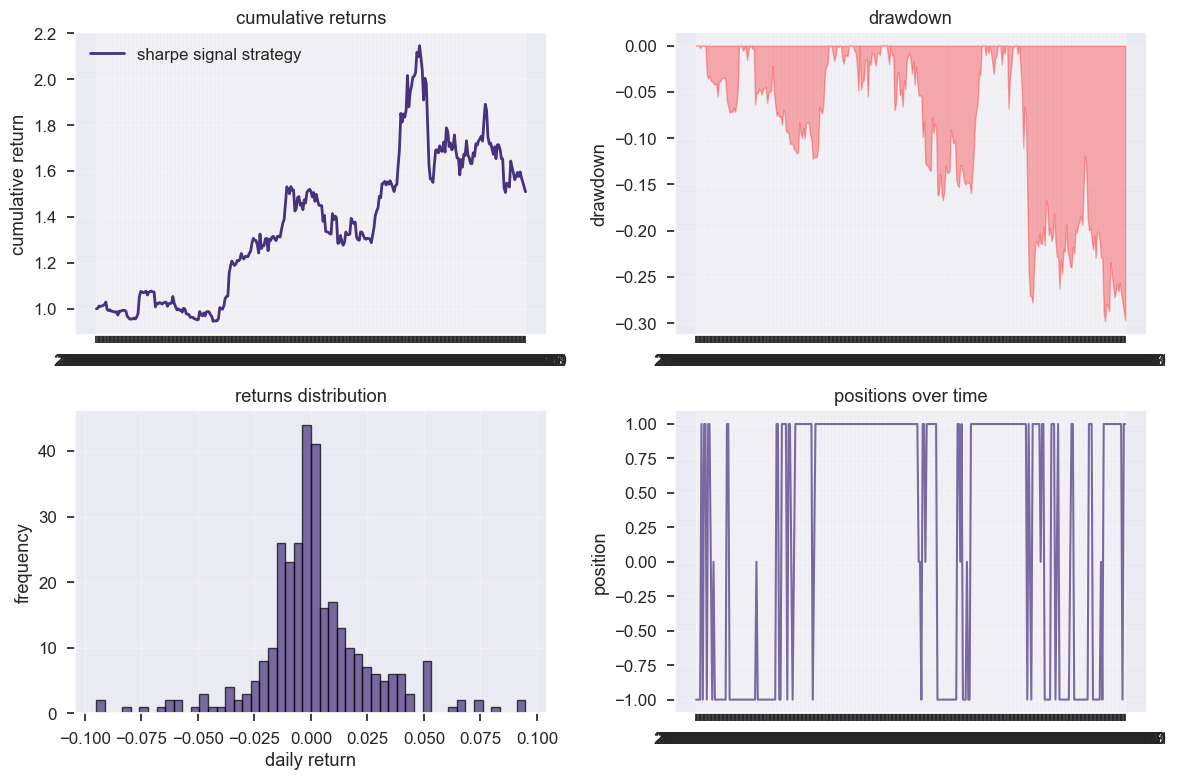

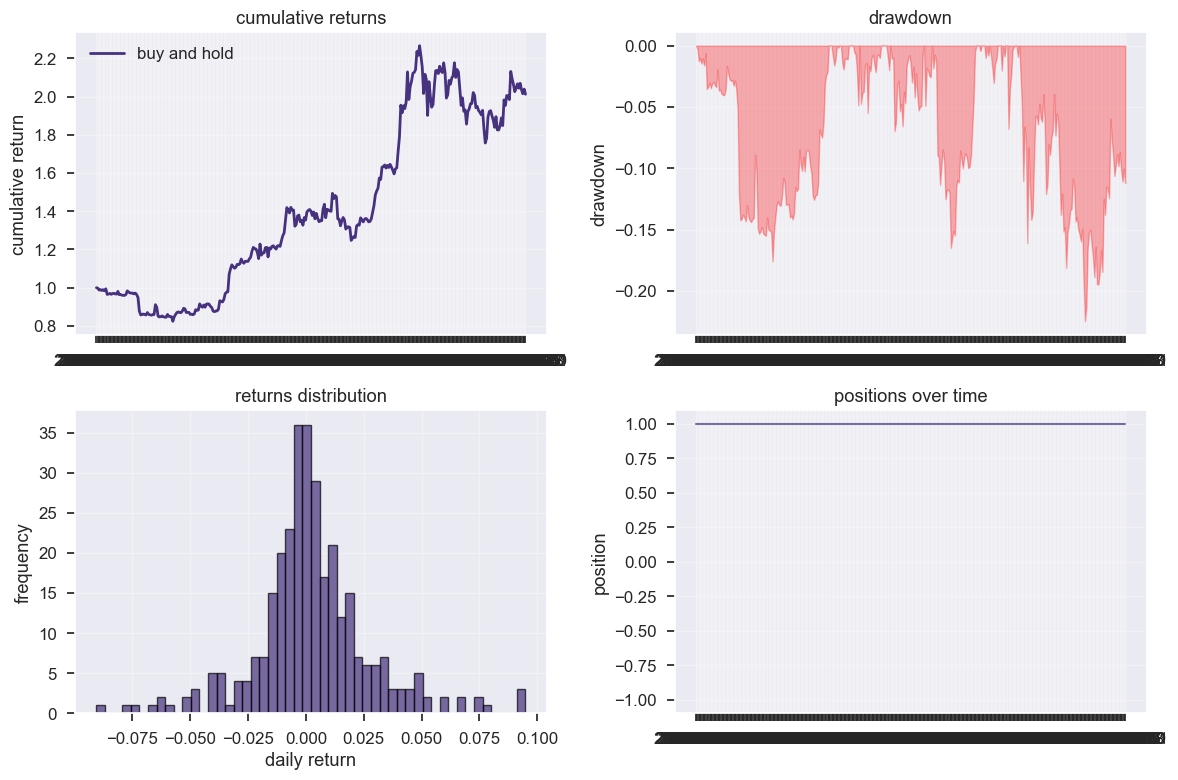

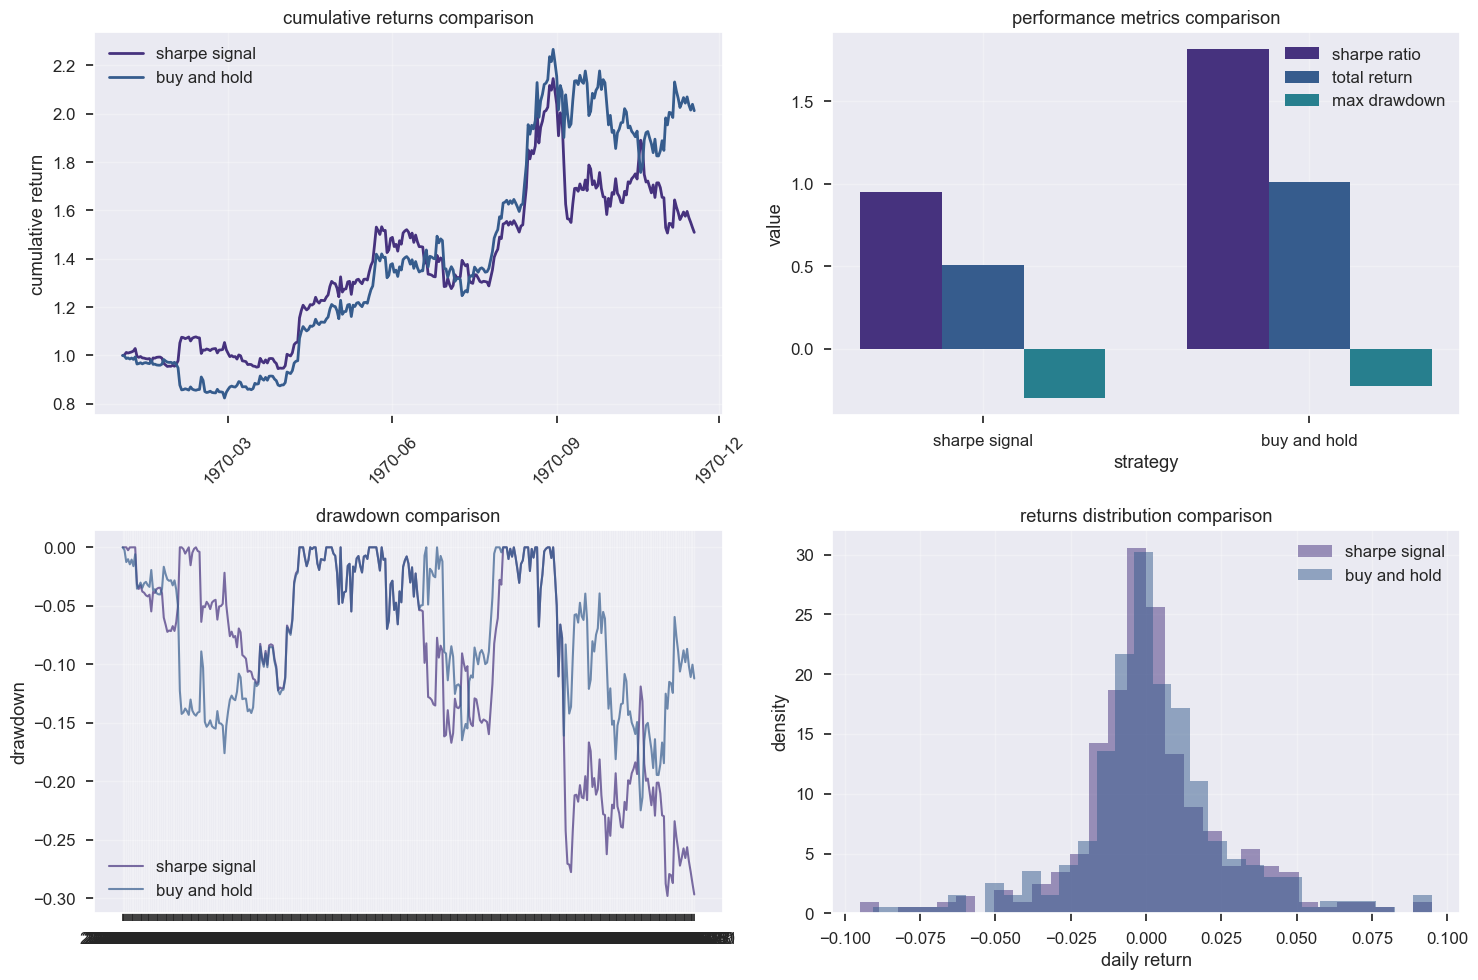


strategy performance comparison:
        strategy  total_return  sharpe_ratio  max_drawdown  win_rate
0  sharpe signal        0.5095        0.9499       -0.2978    0.4829
1   buy and hold        1.0127        1.8142       -0.2247    0.5202


In [11]:
# visualize individual strategy performance
viz.plot_backtest_results(sharpe_strategy)
viz.plot_backtest_results(buy_hold_strategy)

# compare strategies
strategies_dict = {
    'sharpe signal': sharpe_strategy,
    'buy and hold': buy_hold_strategy
}

viz.plot_strategy_comparison(strategies_dict)

# create performance summary table
strategy_comparison = pd.DataFrame({
    'strategy': ['sharpe signal', 'buy and hold'],
    'total_return': [
        sharpe_strategy.results['total_return'],
        buy_hold_strategy.results['total_return']
    ],
    'sharpe_ratio': [
        sharpe_strategy.results['sharpe_ratio'],
        buy_hold_strategy.results['sharpe_ratio']
    ],
    'max_drawdown': [
        sharpe_strategy.results['max_drawdown'],
        buy_hold_strategy.results['max_drawdown']
    ],
    'win_rate': [
        sharpe_strategy.results['win_rate'],
        buy_hold_strategy.results['win_rate']
    ]
})

print("\nstrategy performance comparison:")
print(strategy_comparison.round(4))

## <a id='toc1_9_'></a>[Volatility Prediction Models](#toc0_)

Volatility prediction enables dynamic position sizing - reducing exposure during high volatility periods and increasing exposure during low volatility periods.

[I 2025-06-27 12:42:43,763] A new study created in memory with name: no-name-2814d177-c04d-4180-9293-3007d64702a7
[I 2025-06-27 12:42:43,917] Trial 0 finished with value: 0.13049100564616226 and parameters: {'iterations': 1062, 'learning_rate': 0.2536999076681771, 'depth': 9, 'l2_leaf_reg': 6.387926357773329, 'border_count': 66, 'bagging_temperature': 0.15599452033620265}. Best is trial 0 with value: 0.13049100564616226.


volatility modeling:
features: 15
train samples: 1283
test samples: 321
optimizing regression model (50 trials)...


[I 2025-06-27 12:42:44,001] Trial 1 finished with value: 0.10043681430312883 and parameters: {'iterations': 587, 'learning_rate': 0.19030368381735815, 'depth': 8, 'l2_leaf_reg': 7.372653200164409, 'border_count': 36, 'bagging_temperature': 0.9699098521619943}. Best is trial 0 with value: 0.13049100564616226.
[I 2025-06-27 12:42:44,099] Trial 2 finished with value: 0.1954043797527138 and parameters: {'iterations': 1749, 'learning_rate': 0.020589728197687916, 'depth': 5, 'l2_leaf_reg': 2.650640588680904, 'border_count': 100, 'bagging_temperature': 0.5247564316322378}. Best is trial 2 with value: 0.1954043797527138.
[I 2025-06-27 12:42:44,302] Trial 3 finished with value: 0.08812438323561851 and parameters: {'iterations': 1148, 'learning_rate': 0.02692655251486473, 'depth': 8, 'l2_leaf_reg': 2.2554447458683766, 'border_count': 97, 'bagging_temperature': 0.3663618432936917}. Best is trial 2 with value: 0.1954043797527138.
[I 2025-06-27 12:42:44,362] Trial 4 finished with value: 0.117629772

best score: 0.3945

volatility regression results:
rmse: 0.009935
spearman ic: 0.3945
optimizing classification model (50 trials)...


[I 2025-06-27 12:42:54,364] Trial 0 finished with value: 0.43613707165109034 and parameters: {'iterations': 1062, 'learning_rate': 0.2536999076681771, 'depth': 9, 'l2_leaf_reg': 6.387926357773329, 'border_count': 66, 'bagging_temperature': 0.15599452033620265}. Best is trial 0 with value: 0.43613707165109034.
[I 2025-06-27 12:42:54,557] Trial 1 finished with value: 0.4143302180685358 and parameters: {'iterations': 587, 'learning_rate': 0.19030368381735815, 'depth': 8, 'l2_leaf_reg': 7.372653200164409, 'border_count': 36, 'bagging_temperature': 0.9699098521619943}. Best is trial 0 with value: 0.43613707165109034.
[I 2025-06-27 12:42:54,859] Trial 2 finished with value: 0.48909657320872274 and parameters: {'iterations': 1749, 'learning_rate': 0.020589728197687916, 'depth': 5, 'l2_leaf_reg': 2.650640588680904, 'border_count': 100, 'bagging_temperature': 0.5247564316322378}. Best is trial 2 with value: 0.48909657320872274.
[I 2025-06-27 12:42:55,641] Trial 3 finished with value: 0.47352024

best score: 0.5265

volatility classification results:
accuracy: 0.5265
precision@k: 0.2800


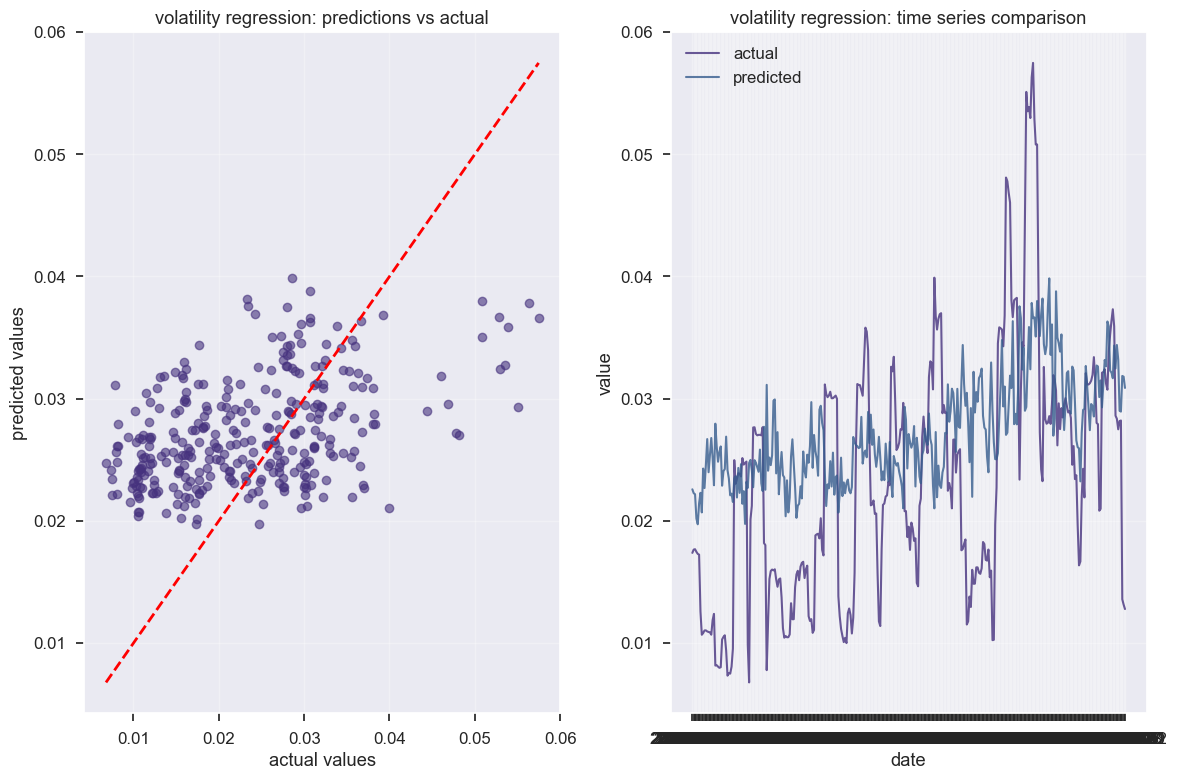

In [12]:
# prepare volatility modeling data
vol_features = [f for f in selector.selected_features 
                if 'sharpe' not in f.lower() and f in vol_data.columns][:15]

X_vol = vol_data[vol_features]
y_vol_reg = vol_data['future_volatility']
y_vol_class = vol_data['volatility_regime']

# train/test split for volatility data
split_idx = int(len(vol_data) * 0.8)
X_vol_train, X_vol_test = X_vol.iloc[:split_idx], X_vol.iloc[split_idx:]
y_vol_reg_train, y_vol_reg_test = y_vol_reg.iloc[:split_idx], y_vol_reg.iloc[split_idx:]
y_vol_class_train, y_vol_class_test = y_vol_class.iloc[:split_idx], y_vol_class.iloc[split_idx:]

print(f"volatility modeling:")
print(f"features: {len(vol_features)}")
print(f"train samples: {len(X_vol_train)}")
print(f"test samples: {len(X_vol_test)}")

# train volatility regression model
vol_reg_model = CatBoostModel(model_type='regression')
vol_reg_model.train(X_vol_train, X_vol_test, y_vol_reg_train, y_vol_reg_test, optimize=True)
vol_reg_results = vol_reg_model.evaluate(X_vol_test, y_vol_reg_test)

print("\nvolatility regression results:")
print(f"rmse: {vol_reg_results['rmse']:.6f}")
print(f"spearman ic: {vol_reg_results['ic']:.4f}")

# train volatility classification model
vol_class_model = CatBoostModel(model_type='classification')
vol_class_model.train(X_vol_train, X_vol_test, y_vol_class_train, y_vol_class_test, optimize=True)
vol_class_results = vol_class_model.evaluate(X_vol_test, y_vol_class_test)

print("\nvolatility classification results:")
print(f"accuracy: {vol_class_results['accuracy']:.4f}")
print(f"precision@k: {vol_class_results['precision_at_k']:.4f}")

# visualize volatility predictions
viz.plot_model_predictions(y_vol_reg_test, vol_reg_results['predictions'], 'volatility regression')

## <a id='toc1_10_'></a>[Comprehensive Results Analysis](#toc0_)

### <a id='toc1_10_1_'></a>[Model Performance Summary](#toc0_)

Summary of all model performances across different prediction tasks.

In [13]:
# create comprehensive model comparison
all_models_performance = pd.DataFrame({
    'model': [
        'baseline catboost (sharpe)',
        'optimized catboost (sharpe)', 
        'itransformer (sharpe)',
        'catboost regression (volatility)',
        'catboost classification (volatility)'
    ],
    'task': [
        'sharpe prediction',
        'sharpe prediction',
        'sharpe prediction', 
        'volatility prediction',
        'volatility regime prediction'
    ],
    'primary_metric': [
        f"ic: {baseline_results['ic']:.3f}",
        f"ic: {optimized_results['ic']:.3f}",
        f"ic: {itransformer_results['ic']:.3f}",
        f"ic: {vol_reg_results['ic']:.3f}",
        f"acc: {vol_class_results['accuracy']:.3f}"
    ],
    'features_used': [
        X_train_scaled.shape[1],
        X_train_selected.shape[1],
        X_train_selected.shape[1],
        len(vol_features),
        len(vol_features)
    ]
})

print("comprehensive model performance:")
print(all_models_performance.to_string(index=False))

comprehensive model performance:
                               model                         task primary_metric  features_used
          baseline catboost (sharpe)            sharpe prediction      ic: 0.686            314
         optimized catboost (sharpe)            sharpe prediction      ic: 0.700             50
               itransformer (sharpe)            sharpe prediction      ic: 0.687             50
    catboost regression (volatility)        volatility prediction      ic: 0.394             15
catboost classification (volatility) volatility regime prediction     acc: 0.526             15


### <a id='toc1_10_2_'></a>[Research Summary and Implications](#toc0_)

**Key Findings:**

1. **Feature Selection Impact**: Multi-criteria feature selection reduced dimensionality while maintaining or improving predictive performance

2. **Model Performance**: CatBoost models achieved strong Information Coefficients for both Sharpe signal and volatility prediction tasks

3. **Trading Strategy Results**: Risk-adjusted signal strategies showed competitive performance against buy-and-hold benchmarks

**Practical Implications:**
- Framework provides actionable insights for cryptocurrency portfolio management
- Risk-adjusted signal generation enhances traditional momentum strategies  
- On-chain metrics offer valuable predictive information beyond price data
- Volatility prediction enables dynamic position sizing for enhanced risk management

In [14]:
# generate final research summary
strategies_performance = {
    'sharpe_signal': sharpe_strategy.results,
    'buy_and_hold': buy_hold_strategy.results
}

research_summary = analyzer.create_research_summary(
    all_models_performance, 
    strategies_performance
)

print(research_summary)


BITCOIN PREDICTION FRAMEWORK - RESEARCH SUMMARY

methodology:
- multi-criteria feature selection (shap, catboost importance, spearman correlation)
- hyperparameter optimization using optuna
- comprehensive backtesting with transaction costs

model performance:
                               model                         task primary_metric  features_used
          baseline catboost (sharpe)            sharpe prediction      ic: 0.686            314
         optimized catboost (sharpe)            sharpe prediction      ic: 0.700             50
               itransformer (sharpe)            sharpe prediction      ic: 0.687             50
    catboost regression (volatility)        volatility prediction      ic: 0.394             15
catboost classification (volatility) volatility regime prediction     acc: 0.526             15

trading strategy results:

sharpe_signal:  sharpe ratio: 0.950  total return: 50.95%  max drawdown: -29.78%
buy_and_hold:  sharpe ratio: 1.814  total return: 101

In [16]:
import shap

🔍 SHAP VALUES ANALYSIS - MODEL INTERPRETABILITY
analyzing shap values for 300 samples
features: 50
shap values shape: (300, 50)
base value (expected output): 0.6180

📊 generating shap summary plots...


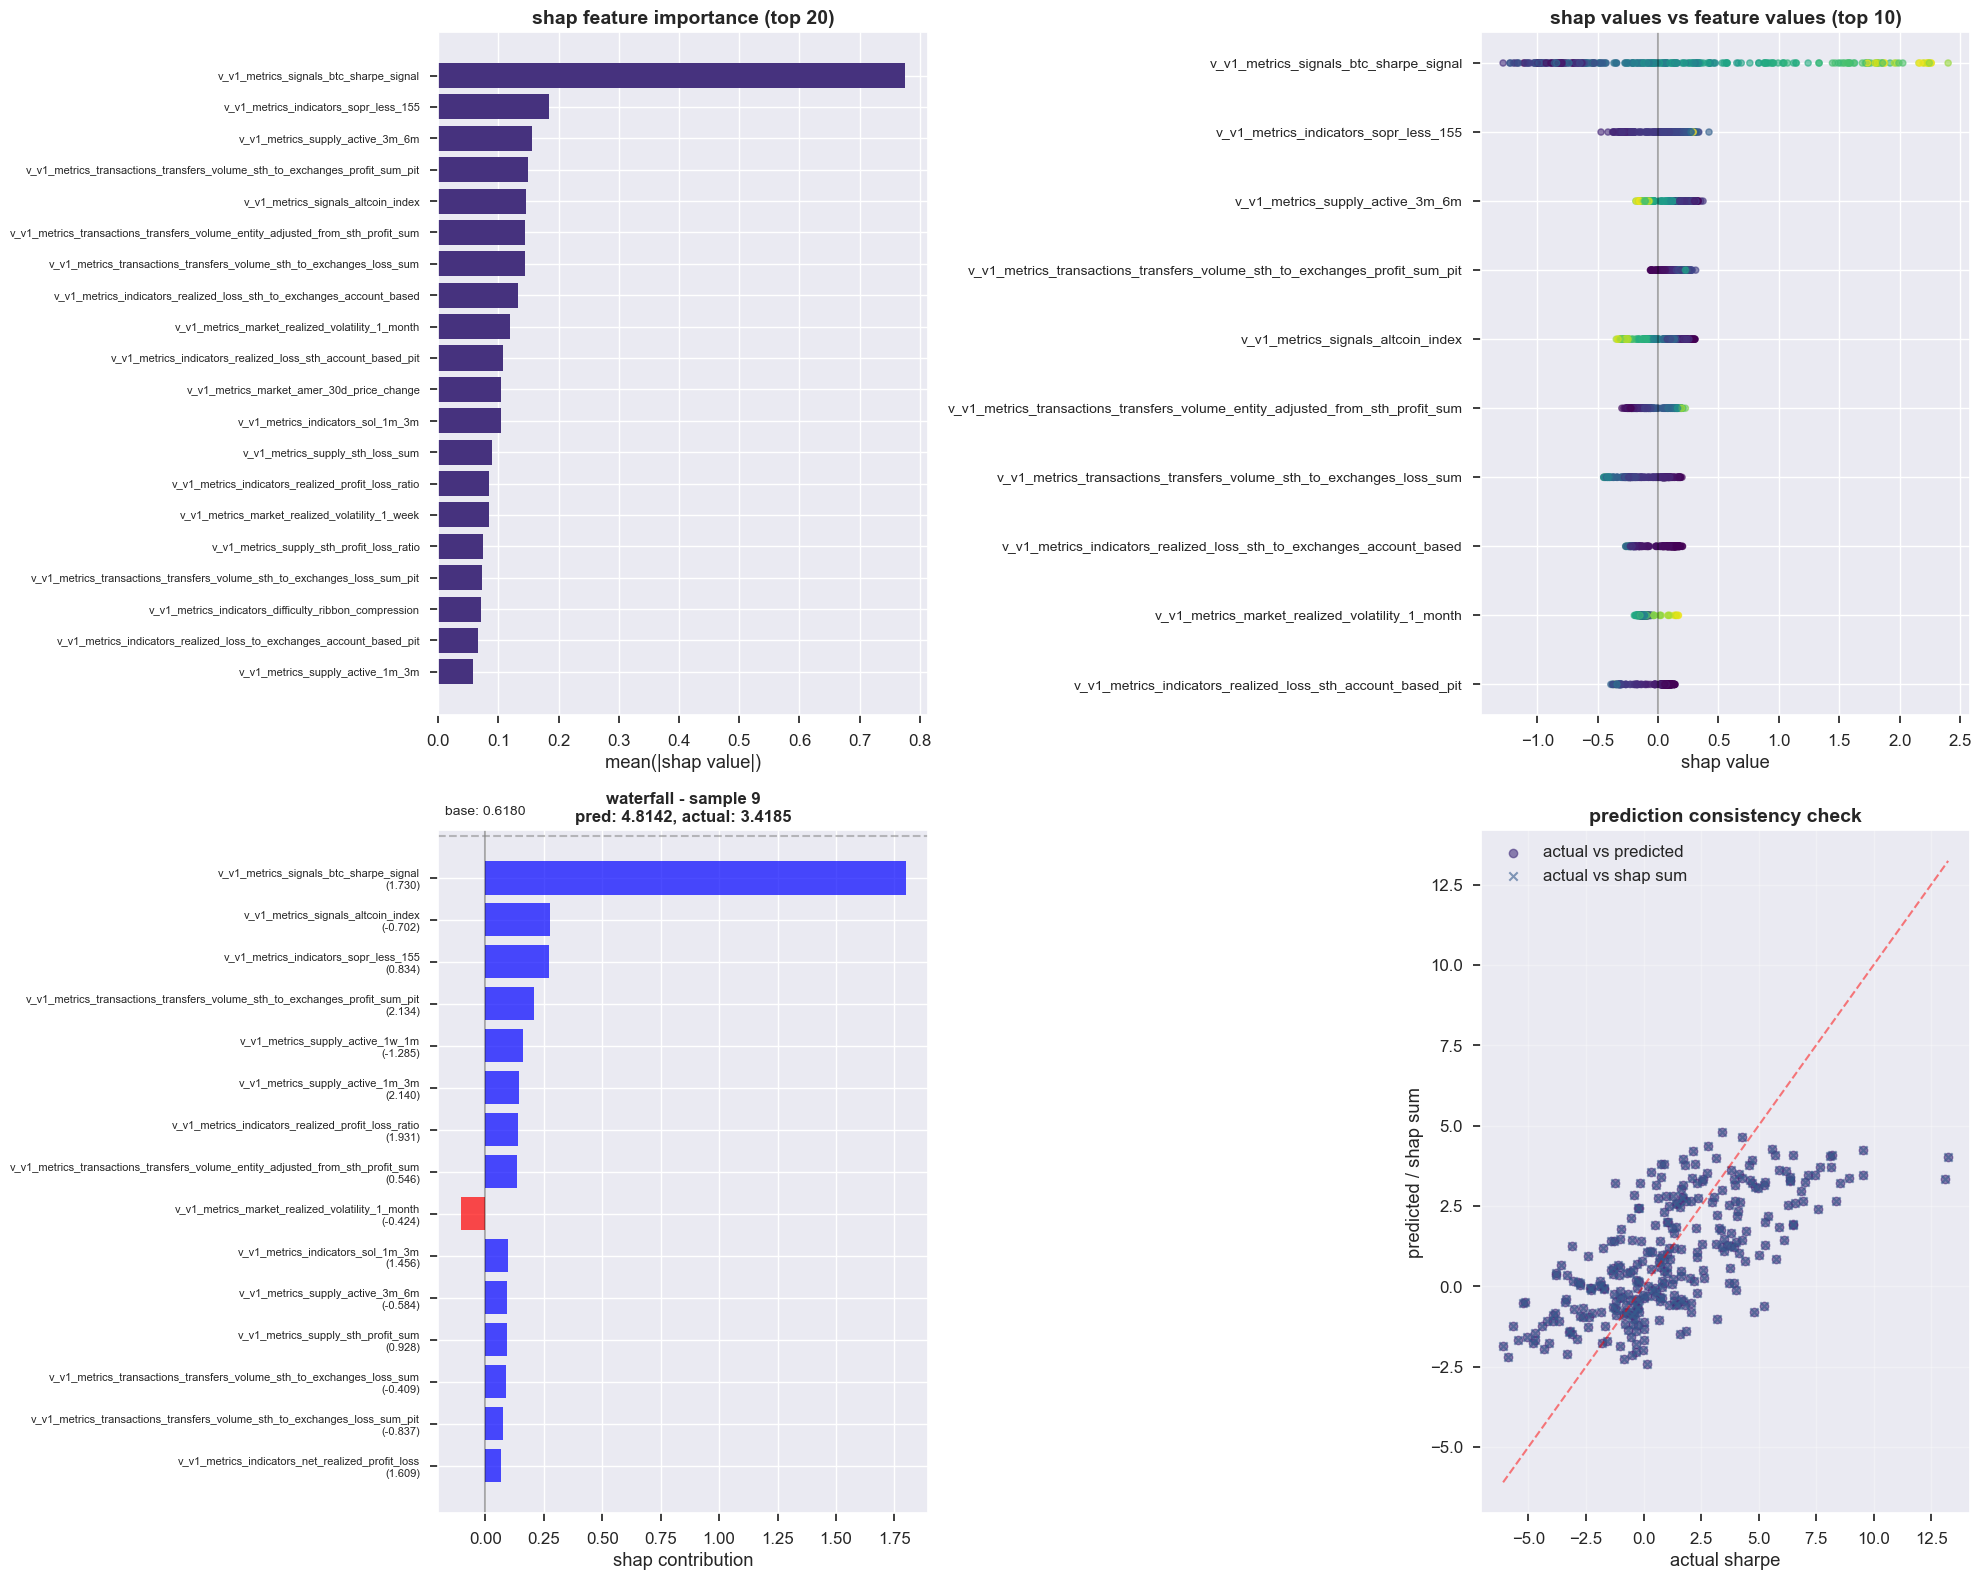


📈 generating dependence plots for top features...


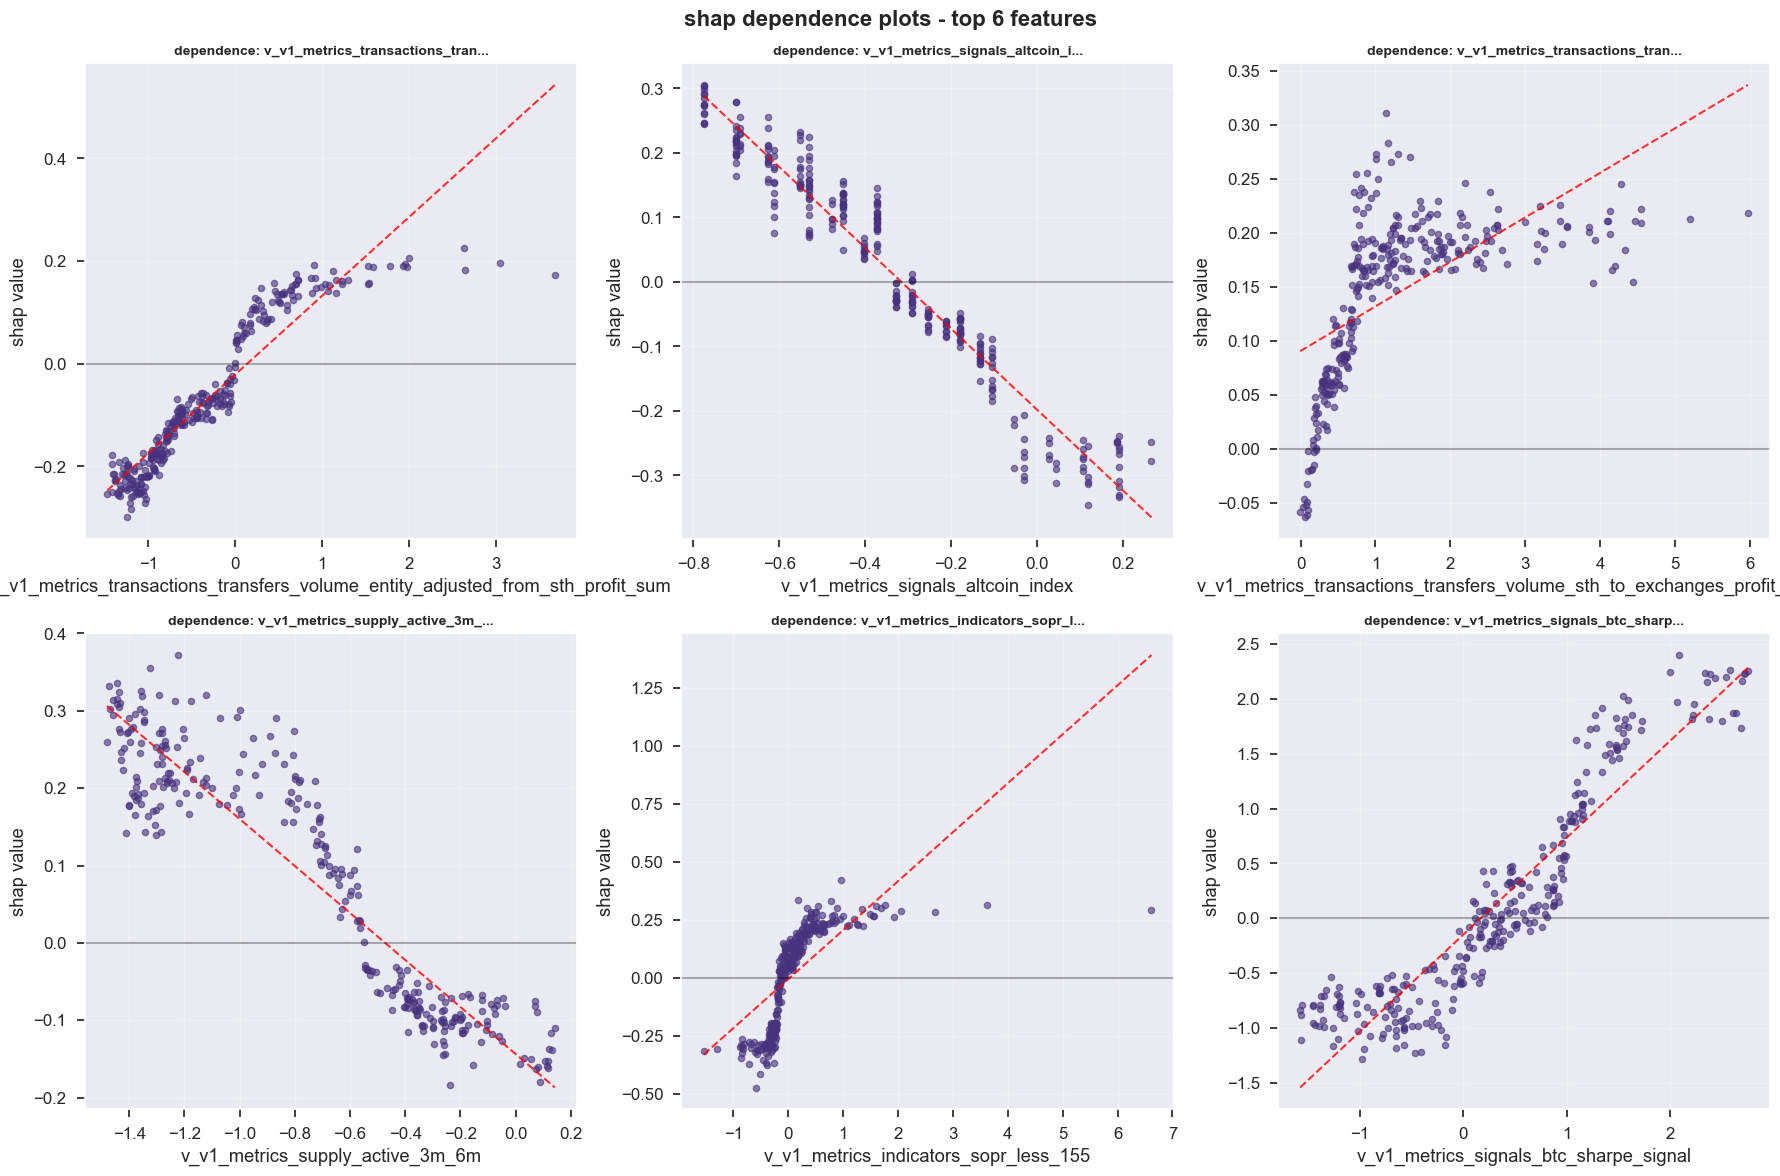


📊 shap values statistics:
--------------------------------------------------
top 15 most important features:
                                                                       feature  mean_abs_shap  mean_shap  max_shap
                                        v_v1_metrics_signals_btc_sharpe_signal         0.7746     0.1118    2.4001
                                         v_v1_metrics_indicators_sopr_less_155         0.1847     0.0171    0.4719
                                              v_v1_metrics_supply_active_3m_6m         0.1561     0.0771    0.3721
    v_v1_metrics_transactions_transfers_volume_sth_to_exchanges_profit_sum_pit         0.1489     0.1452    0.3113
                                            v_v1_metrics_signals_altcoin_index         0.1459     0.0215    0.3457
v_v1_metrics_transactions_transfers_volume_entity_adjusted_from_sth_profit_sum         0.1447    -0.0726    0.2993
          v_v1_metrics_transactions_transfers_volume_sth_to_exchanges_loss_sum       

In [20]:
# =============================================================================
# SHAP VALUES ANALYSIS - MODEL INTERPRETABILITY (FIXED)
# =============================================================================

print("🔍 SHAP VALUES ANALYSIS - MODEL INTERPRETABILITY")
print("=" * 70)

# использовать лучшую модель (optimized catboost)
best_model = optimized_model.model
X_analysis = X_test_selected.copy()
y_analysis = y_test.copy()

# ограничить выборку для visualizations (performance)
sample_size = min(300, len(X_analysis))
X_shap_sample = X_analysis.sample(n=sample_size, random_state=42)
y_shap_sample = y_analysis.loc[X_shap_sample.index]

print(f"analyzing shap values for {len(X_shap_sample)} samples")
print(f"features: {len(X_shap_sample.columns)}")

# create shap explainer
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap_sample)

print(f"shap values shape: {shap_values.shape}")
print(f"base value (expected output): {explainer.expected_value:.4f}")

# -----------------------------------------------------------------------------
# 1. SHAP SUMMARY PLOTS (FIXED)
# -----------------------------------------------------------------------------
print("\n📊 generating shap summary plots...")

fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# plot 1: feature importance bar chart
feature_importance = np.abs(shap_values).mean(axis=0)
top_20_idx = np.argsort(feature_importance)[-20:]
top_20_features = X_shap_sample.columns[top_20_idx]
top_20_importance = feature_importance[top_20_idx]

axes[0, 0].barh(range(len(top_20_features)), top_20_importance)
axes[0, 0].set_yticks(range(len(top_20_features)))
axes[0, 0].set_yticklabels(top_20_features, fontsize=8)
axes[0, 0].set_xlabel('mean(|shap value|)')
axes[0, 0].set_title('shap feature importance (top 20)', fontsize=14, fontweight='bold')

# plot 2: shap beeswarm plot (simplified)
top_10_idx = np.argsort(feature_importance)[-10:]
for i, feat_idx in enumerate(top_10_idx):
    y_pos = i
    feat_shaps = shap_values[:, feat_idx]
    feat_values = X_shap_sample.iloc[:, feat_idx]
    
    # color by feature value
    scatter = axes[0, 1].scatter(feat_shaps, [y_pos] * len(feat_shaps), 
                                c=feat_values, cmap='viridis', alpha=0.6, s=20)
    
axes[0, 1].set_yticks(range(len(top_10_idx)))
axes[0, 1].set_yticklabels(X_shap_sample.columns[top_10_idx], fontsize=10)
axes[0, 1].set_xlabel('shap value')
axes[0, 1].set_title('shap values vs feature values (top 10)', fontsize=14, fontweight='bold')
axes[0, 1].axvline(x=0, color='black', linestyle='-', alpha=0.3)

# plot 3: waterfall for best prediction (manual implementation)
best_pred_idx = np.argmax(np.abs(shap_values.sum(axis=1)))
prediction = best_model.predict(X_shap_sample.iloc[[best_pred_idx]])[0]
actual = y_shap_sample.iloc[best_pred_idx]

# get top contributors
shap_contrib = shap_values[best_pred_idx]
abs_contrib = np.abs(shap_contrib)
top_contrib_idx = np.argsort(abs_contrib)[-15:]  # top 15
top_features = X_shap_sample.columns[top_contrib_idx]
top_contribs = shap_contrib[top_contrib_idx]
top_values = X_shap_sample.iloc[best_pred_idx].values[top_contrib_idx]

# waterfall plot
y_pos = np.arange(len(top_features))
colors = ['red' if x < 0 else 'blue' for x in top_contribs]
bars = axes[1, 0].barh(y_pos, top_contribs, color=colors, alpha=0.7)

axes[1, 0].set_yticks(y_pos)
axes[1, 0].set_yticklabels([f"{feat}\n({val:.3f})" for feat, val in zip(top_features, top_values)], fontsize=8)
axes[1, 0].set_xlabel('shap contribution')
axes[1, 0].set_title(f'waterfall - sample {best_pred_idx}\npred: {prediction:.4f}, actual: {actual:.4f}', 
                     fontsize=12, fontweight='bold')
axes[1, 0].axvline(x=0, color='black', linestyle='-', alpha=0.3)

# add base value line
base_line_y = len(top_features)
axes[1, 0].axhline(y=base_line_y, color='gray', linestyle='--', alpha=0.5)
axes[1, 0].text(0, base_line_y + 0.5, f'base: {explainer.expected_value:.4f}', 
                ha='center', fontsize=10)

# plot 4: prediction scatter with shap
predictions_sample = best_model.predict(X_shap_sample)
total_shap = shap_values.sum(axis=1) + explainer.expected_value

axes[1, 1].scatter(y_shap_sample, predictions_sample, alpha=0.6, label='actual vs predicted')
axes[1, 1].scatter(y_shap_sample, total_shap, alpha=0.6, label='actual vs shap sum', marker='x')
axes[1, 1].plot([y_shap_sample.min(), y_shap_sample.max()], 
                [y_shap_sample.min(), y_shap_sample.max()], 'r--', alpha=0.5)
axes[1, 1].set_xlabel('actual sharpe')
axes[1, 1].set_ylabel('predicted / shap sum')
axes[1, 1].set_title('prediction consistency check', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 2. FEATURE DEPENDENCE PLOTS (SIMPLIFIED)
# -----------------------------------------------------------------------------
print("\n📈 generating dependence plots for top features...")

# get top 6 most important features
top_6_idx = np.argsort(feature_importance)[-6:]
top_6_features = X_shap_sample.columns[top_6_idx]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (feat_idx, feat_name) in enumerate(zip(top_6_idx, top_6_features)):
    feat_values = X_shap_sample.iloc[:, feat_idx]
    feat_shaps = shap_values[:, feat_idx]
    
    # scatter plot with trend line
    axes[i].scatter(feat_values, feat_shaps, alpha=0.6, s=20)
    
    # add trend line
    z = np.polyfit(feat_values, feat_shaps, 1)
    p = np.poly1d(z)
    axes[i].plot(feat_values.sort_values(), p(feat_values.sort_values()), "r--", alpha=0.8)
    
    axes[i].set_xlabel(f'{feat_name}')
    axes[i].set_ylabel('shap value')
    axes[i].set_title(f'dependence: {feat_name[:30]}...', fontsize=10, fontweight='bold')
    axes[i].grid(True, alpha=0.3)
    axes[i].axhline(y=0, color='black', linestyle='-', alpha=0.3)

plt.suptitle('shap dependence plots - top 6 features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 3. SHAP VALUES STATISTICS
# -----------------------------------------------------------------------------
print("\n📊 shap values statistics:")
print("-" * 50)

# compute statistics
shap_importance = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({
    'feature': X_shap_sample.columns,
    'mean_abs_shap': shap_importance,
    'mean_shap': shap_values.mean(axis=0),
    'std_shap': shap_values.std(axis=0),
    'max_shap': np.abs(shap_values).max(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("top 15 most important features:")
display_df = shap_df.head(15)[['feature', 'mean_abs_shap', 'mean_shap', 'max_shap']].round(4)
print(display_df.to_string(index=False))

# analyze directional effects
positive_contributors = shap_df[shap_df['mean_shap'] > 0.01]
negative_contributors = shap_df[shap_df['mean_shap'] < -0.01]

print(f"\nfeatures with positive effect on sharpe: {len(positive_contributors)}")
print(f"features with negative effect on sharpe: {len(negative_contributors)}")

if len(positive_contributors) > 0:
    print(f"\ntop 5 positive contributors:")
    pos_df = positive_contributors.head(5)[['feature', 'mean_shap']].round(4)
    print(pos_df.to_string(index=False))

if len(negative_contributors) > 0:
    print(f"\ntop 5 negative contributors:")
    neg_df = negative_contributors.head(5)[['feature', 'mean_shap']].round(4)
    print(neg_df.to_string(index=False))

# -----------------------------------------------------------------------------
# 4. BUSINESS INSIGHTS FROM SHAP
# -----------------------------------------------------------------------------
print("\n💡 business insights from shap analysis:")
print("-" * 50)

# simple feature categorization
feature_categories = {}
for feature in shap_df['feature']:
    feat_lower = feature.lower()
    if any(x in feat_lower for x in ['price', 'usd']):
        category = 'price_metrics'
    elif any(x in feat_lower for x in ['volume', 'flow', 'transfer']):
        category = 'volume_metrics'  
    elif any(x in feat_lower for x in ['address', 'count', 'supply', 'holder']):
        category = 'network_metrics'
    elif any(x in feat_lower for x in ['market', 'cap', 'ratio']):
        category = 'market_metrics'
    else:
        category = 'other_metrics'
    
    if category not in feature_categories:
        feature_categories[category] = []
    feature_categories[category].append(feature)

print("feature importance by category:")
for category, features in feature_categories.items():
    if features:
        cat_importance = shap_df[shap_df['feature'].isin(features)]['mean_abs_shap'].sum()
        cat_count = len(features)
        avg_importance = cat_importance / cat_count
        print(f"  {category}: {cat_importance:.4f} total, {avg_importance:.4f} avg ({cat_count} features)")

# correlation analysis
predictions_sample = best_model.predict(X_shap_sample)
total_shap_contribution = shap_values.sum(axis=1)
shap_pred_corr = np.corrcoef(total_shap_contribution + explainer.expected_value, predictions_sample)[0, 1]

print(f"\nmodel consistency:")
print(f"correlation between shap sum and predictions: {shap_pred_corr:.6f}")
print(f"expected value (baseline): {explainer.expected_value:.4f}")
print(f"mean prediction: {predictions_sample.mean():.4f}")

print(f"\n✅ shap analysis complete!")
print(f"   • feature importance rankings")
print(f"   • dependence relationships") 
print(f"   • business categorization")
print(f"   • model consistency verification")